In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the CSV file into a DataFrame
df = pd.read_csv('../data/raw/seoul_bike_sharing_demand.csv')

warnings.filterwarnings("ignore", category=UserWarning)

Objective: How accurately can hourly bike rental demand be predicted using weather, time, and operating conditions?

## EDA

In [2]:
df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day
0,1/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,1/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,1/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,1/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,1/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [3]:
df.dtypes

Date                         str
Rented Bike Count          int64
Hour                       int64
Temperature              float64
Humidity                   int64
Wind speed               float64
Visibility                 int64
Dew point temperature    float64
Solar Radiation          float64
Rainfall                 float64
Snowfall                 float64
Seasons                      str
Holiday                      str
Functioning Day              str
dtype: object

In [4]:
df['Holiday'].value_counts()

Holiday
No Holiday    8328
Holiday        432
Name: count, dtype: int64

In [5]:
df['Functioning Day'].value_counts()

Functioning Day
Yes    8465
No      295
Name: count, dtype: int64

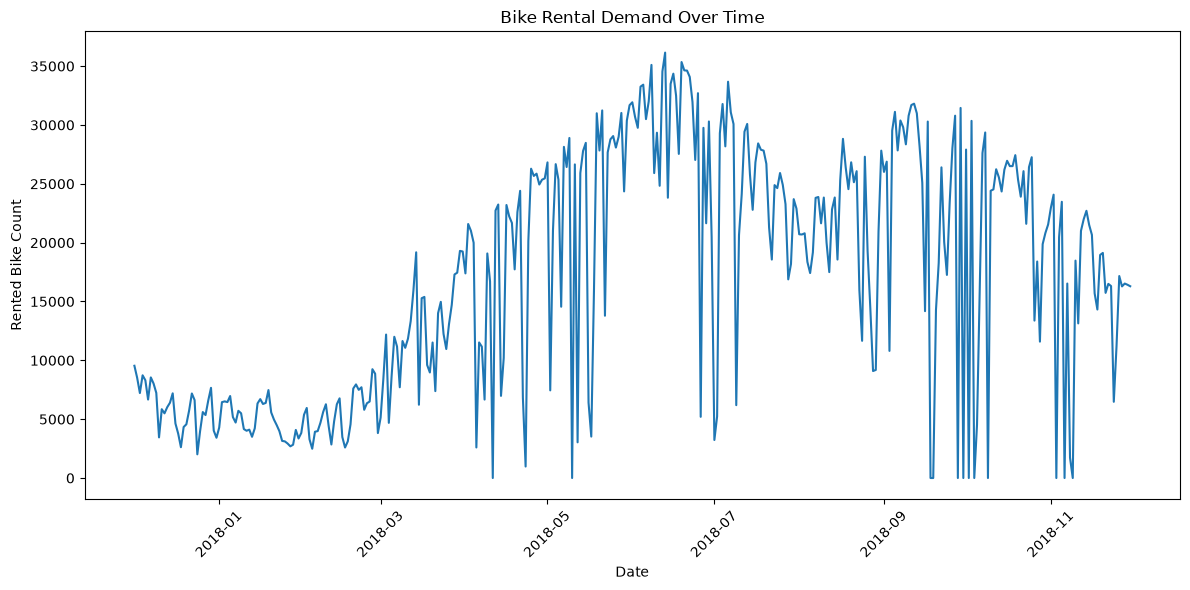

In [6]:
# Find the distribution of bike rental demand over time (line plot)
plt.figure(figsize=(12, 6))

# Convert 'Date' column to datetime format
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Sum the rented bike count for each date
agg_demand_df = df.groupby("Date")["Rented Bike Count"].sum().reset_index()

plt.plot(agg_demand_df['Date'], agg_demand_df['Rented Bike Count'])
plt.title('Bike Rental Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Rented Bike Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# IQR method to detect outliers in the 'Rented Bike Count' column
# Use the original DataFrame since we want hourly data for outlier detection
Q1 = df['Rented Bike Count'].quantile(0.25)
Q3 = df['Rented Bike Count'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create a new column 'Outlier' to indicate whether each row is an outlier or not
df['Outlier'] = (
    (df['Rented Bike Count'] < lower_bound) |
    (df['Rented Bike Count'] > upper_bound)
)

df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Outlier
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,False
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,False
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,False
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,False
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,False


In [8]:
df['Outlier'].value_counts()

Outlier
False    8602
True      158
Name: count, dtype: int64

In [9]:
# Filter the DataFrame to show only the rows where 'Outlier' is True and 'Functioning Day' is 'No'
# Functioning day indicates whether the service was operational on that day
# No functionaing day means low or no demand
df[df['Outlier']]['Functioning Day'].value_counts()

Functioning Day
Yes    158
Name: count, dtype: int64

In [10]:
df['Hour'].value_counts()

Hour
0     365
1     365
2     365
3     365
4     365
5     365
6     365
7     365
8     365
9     365
10    365
11    365
12    365
13    365
14    365
15    365
16    365
17    365
18    365
19    365
20    365
21    365
22    365
23    365
Name: count, dtype: int64

In [11]:
# Range of dataset
df['Date'].min(), df['Date'].max()

(Timestamp('2017-12-01 00:00:00'), Timestamp('2018-11-30 00:00:00'))

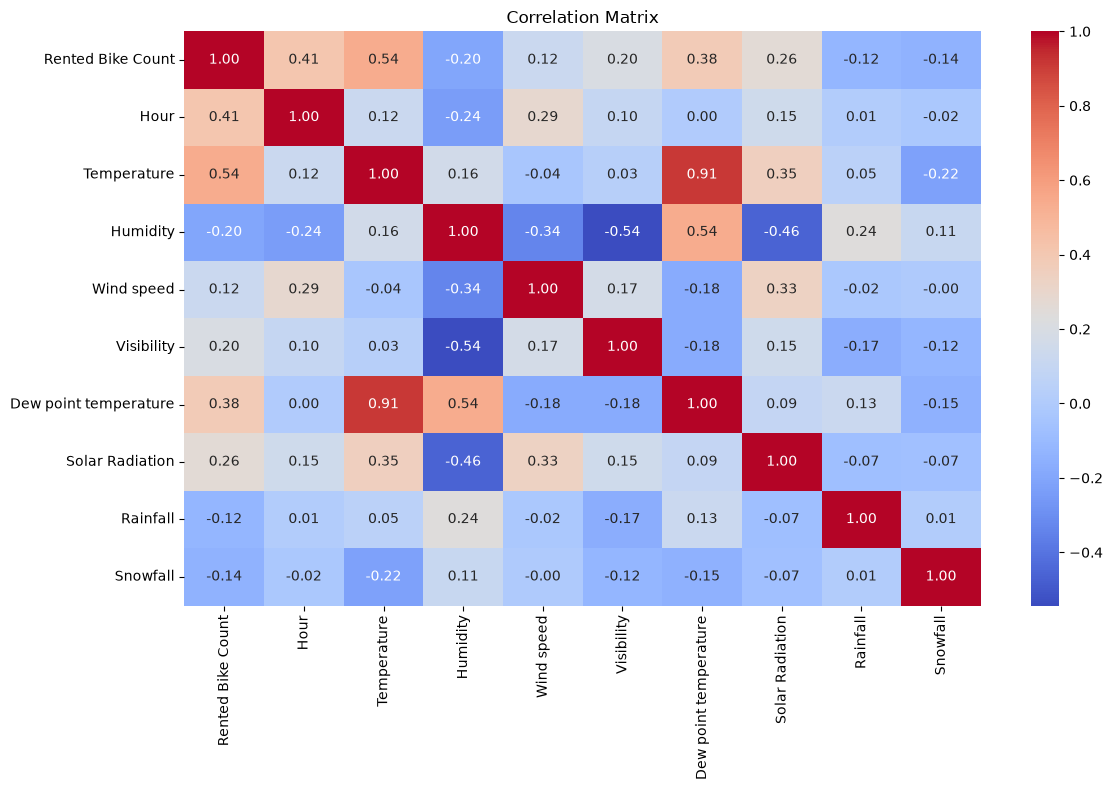

In [12]:
# Correlation between features and target variable 'Rented Bike Count'
numeric_df = df.select_dtypes(include='number')  # Select only numeric columns

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Key Finding
- Bike usage tends to be higher at warmer temperatures (r = 0.54)
- Demand varies by hour (r = 0.41), although correlation understates its likely non-linear rush-hour pattern
- Dew point is moderately associated with demand (r = 0.38), but it overlaps heavily with temperature; will retain temperature only
- Humidity, rainfall, and snowfall have negative associations, consistent with less favorable riding conditions

In [13]:
# Check for null / duplicate values
null_values = df.isnull().sum()
duplicate_values = df.duplicated().sum()

print(f"Null values in each column:\n {null_values}")
print(f"Duplicate values in the dataset:\n {duplicate_values}")

Null values in each column:
 Date                     0
Rented Bike Count        0
Hour                     0
Temperature              0
Humidity                 0
Wind speed               0
Visibility               0
Dew point temperature    0
Solar Radiation          0
Rainfall                 0
Snowfall                 0
Seasons                  0
Holiday                  0
Functioning Day          0
Outlier                  0
dtype: int64
Duplicate values in the dataset:
 0


## Feature Engineering

In [14]:
# Create temporal features from the 'Date' column
df['Day_of_Week'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month
df['Is_Weekend'] = (df['Day_of_Week'] >= 5).astype(int)

df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Outlier,Day_of_Week,Month,Is_Weekend
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,False,4,12,0
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,False,4,12,0
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,False,4,12,0
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,False,4,12,0
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,False,4,12,0


In [15]:
# Create lag / rolling features
# Help the model capture temporal dependencies in the data
# For example, the demand at a given hour might be influenced by the demand in the previous hours

# Sort the DataFrame by 'Date' and 'Hour'
df["Datetime"] = df["Date"] + pd.to_timedelta(df["Hour"], unit="h")
df = df.sort_values("Datetime")

# Create lag features for the previous day and week
df["lag_24"] = df["Rented Bike Count"].shift(24)
df["lag_168"] = df["Rented Bike Count"].shift(168)

# Create rolling features for the previous day and week
df["rolling_24"] = df["Rented Bike Count"].shift(1).rolling(24).mean()
df["rolling_168"] = df["Rented Bike Count"].shift(1).rolling(168).mean()

# Drop rows with NaN values in the lag and rolling features (first few rows)
df = df.dropna(subset=[
    'lag_24',
    'lag_168',
    'rolling_24',
    'rolling_168'
])

In [16]:
df['Holiday'].value_counts()

Holiday
No Holiday    8160
Holiday        432
Name: count, dtype: int64

In [17]:
# Binary encode columns ['Holiday', 'Functioning Day']
df['Holiday'] = df['Holiday'].map({'Holiday': 1, 'No Holiday': 0})
df['Functioning Day'] = df['Functioning Day'].map({'Yes': 1, 'No': 0})

In [18]:
# One-hot encode categorical feature 'Seasons'
# Great for low cardinality categorical features
df = pd.get_dummies(df, columns=['Seasons'], drop_first=True)

df.head()

,Date,Rented Bike Count,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,...,Month,Is_Weekend,Datetime,lag_24,lag_168,rolling_24,rolling_168,Seasons_Spring,Seasons_Summer,Seasons_Winter
168,2017-12-08,233,0,-3.5,49,2.6,1893,-12.6,0.0,0.0,...,12,0,2017-12-08 00:00:00,198.0,254.0,356.208333,342.488095,False,False,True
169,2017-12-08,230,1,-3.7,50,2.5,1902,-12.6,0.0,0.0,...,12,0,2017-12-08 01:00:00,218.0,204.0,357.666667,342.363095,False,False,True
170,2017-12-08,131,2,-4.3,53,1.0,1918,-12.4,0.0,0.0,...,12,0,2017-12-08 02:00:00,149.0,173.0,358.166667,342.517857,False,False,True
171,2017-12-08,99,3,-4.8,52,1.6,1978,-13.1,0.0,0.0,...,12,0,2017-12-08 03:00:00,102.0,107.0,357.416667,342.267857,False,False,True
172,2017-12-08,71,4,-5.3,53,2.4,1936,-13.4,0.0,0.0,...,12,0,2017-12-08 04:00:00,62.0,78.0,357.291667,342.220238,False,False,True


In [19]:
# Utilize cyclical encoding for time-sensitive features (e.g., 'Hour', 'Day_of_Week', 'Month')
# This allows the model to understand the relationship between, for example, December (12) and January (1) as being close in time, rather than far apart numerically
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)

df['Day_sin'] = np.sin(2 * np.pi * df['Day_of_Week'] / 7)
df['Day_cos'] = np.cos(2 * np.pi * df['Day_of_Week'] / 7)

df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

## Train / validation / test split

In [20]:
df.dtypes

Date                     datetime64[us]
Rented Bike Count                 int64
Hour                              int64
Temperature                     float64
Humidity                          int64
Wind speed                      float64
Visibility                        int64
Dew point temperature           float64
Solar Radiation                 float64
Rainfall                        float64
Snowfall                        float64
Holiday                           int64
Functioning Day                   int64
Outlier                            bool
Day_of_Week                       int32
Month                             int32
Is_Weekend                        int64
Datetime                 datetime64[us]
lag_24                          float64
lag_168                         float64
rolling_24                      float64
rolling_168                     float64
Seasons_Spring                     bool
Seasons_Summer                     bool
Seasons_Winter                     bool


In [21]:
# Define features and target variable
numeric_features = [
    'Temperature',
    'Humidity',
    'Wind speed',
    'Visibility',
    'Solar Radiation',
    'Rainfall',
    'Snowfall',
    'lag_24',
    'lag_168',
    'rolling_24',
    'rolling_168'
]

binary_features = [
    'Holiday',
    'Functioning Day',
    'Is_Weekend',
    'Seasons_Spring',
    'Seasons_Summer',
    'Seasons_Winter'
]

cyclical_features = [
    'Hour_sin',
    'Hour_cos',
    'Day_sin',
    'Day_cos',
    'Month_sin',
    'Month_cos'
]

features = numeric_features + binary_features + cyclical_features

X = df[features]
y = df['Rented Bike Count']

In [22]:
# Split the dataset into training, validation, and test sets (70% train, 15% validation, 15% test)
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

# Time-based split to avoid data leakage
X_train_raw = X.iloc[:train_size]
X_val_raw = X.iloc[train_size:train_size + val_size]
X_test_raw = X.iloc[train_size + val_size:]

y_train = y.iloc[:train_size]
y_val = y.iloc[train_size:train_size + val_size]
y_test = y.iloc[train_size + val_size:]

## Modeling

In [23]:
X_train_scaled = X_train_raw.copy()
X_val_scaled = X_val_raw.copy()
X_test_scaled = X_test_raw.copy()

In [24]:
# Standardize the numeric features using StandardScaler
scaler = StandardScaler()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train_scaled[numeric_features])
X_val_scaled[numeric_features] = scaler.transform(X_val_scaled[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test_scaled[numeric_features])

In [25]:
# Fit the Linear Regression model
# Might not be the best model due to nonlinearity of the dataset, but serves as a baseline
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](23,)","[157.33,-86.56, 0.31,..., -3.28, 62.36,-10.55]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](23,)","['Temperature','Humidity','Wind speed',...,'Day_cos','Month_sin', 'Month_cos']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-201.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,23
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(22)


In [26]:
# Predict on the validation set
y_val_pred = lr_model.predict(X_val_scaled)

In [27]:
# Evaluate the model's performance on the validation set
mae = mean_absolute_error(y_val, y_val_pred)
mse = mean_squared_error(y_val, y_val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_val_pred)

print(f"Validation MAE (LR): {mae:.2f}")
print(f"Validation MSE (LR): {mse:.2f}")
print(f"Validation RMSE (LR): {rmse:.2f}")
print(f"Validation R² (LR): {r2:.4f}")

Validation MAE (LR): 345.42
Validation MSE (LR): 227568.31
Validation RMSE (LR): 477.04
Validation R² (LR): 0.5619


A linear baseline explained 56.2% of the variance in hourly bike demand. Since exploratory analysis identified strong nonlinear temporal patterns, a nonlinear model may be better suited to capture this complexity.

In [28]:
# Gradient Boosting model for comparison
# Builds trees sequentially, with each new tree correcting errors made by previous trees
# More prone to overfitting; typically requires some form of regularization
gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train_raw, y_train)  # Use raw features as Gradient Boosting can handle unscaled data well

y_val_pred_gb = gb.predict(X_val_raw)

In [29]:
# Evaluate the model's performance on the validation set
mae_gb = mean_absolute_error(y_val, y_val_pred_gb)
mse_gb = mean_squared_error(y_val, y_val_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_val, y_val_pred_gb)

print(f"Validation MAE (GB): {mae_gb:.2f}")
print(f"Validation MSE (GB): {mse_gb:.2f}")
print(f"Validation RMSE (GB): {rmse_gb:.2f}")
print(f"Validation R² (GB): {r2_gb:.4f}")

Validation MAE (GB): 234.34
Validation MSE (GB): 112218.29
Validation RMSE (GB): 334.99
Validation R² (GB): 0.7840


In [30]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 5]
}

# Use TimeSeriesSplit for cross-validation to respect the temporal order of the data
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error'  # Choose model with lowest RMSE
)

grid_search.fit(X_train_raw, y_train)

print(f"Best parameters found: {grid_search.best_params_}")

Best parameters found: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}


In [31]:
# Fit the GB model with optimal hyperparameters
optimal_gb = grid_search.best_estimator_

y_val_pred_optimal_gb = optimal_gb.predict(X_val_raw)

In [32]:
mae_optimal_gb = mean_absolute_error(y_val, y_val_pred_optimal_gb)
mse_optimal_gb = mean_squared_error(y_val, y_val_pred_optimal_gb)
rmse_optimal_gb = np.sqrt(mse_optimal_gb)
r2_optimal_gb = r2_score(y_val, y_val_pred_optimal_gb)

print(f"Validation MAE (Optimal GB): {mae_optimal_gb:.2f}")
print(f"Validation MSE (Optimal GB): {mse_optimal_gb:.2f}")
print(f"Validation RMSE (Optimal GB): {rmse_optimal_gb:.2f}")
print(f"Validation R² (Optimal GB): {r2_optimal_gb:.4f}")

Validation MAE (Optimal GB): 220.72
Validation MSE (Optimal GB): 108951.24
Validation RMSE (Optimal GB): 330.08
Validation R² (Optimal GB): 0.7903


In [33]:
# XGBoost model for comparison
# Parallelized tree boosting; often faster and more efficient than Gradient Boosting
# Penalizes trees that are too complex, helping to prevent overfitting / improve generalization
xgb = XGBRegressor(random_state=42)

xgb.fit(X_train_raw, y_train)

y_val_pred_xgb = xgb.predict(X_val_raw)

In [34]:
mae_xgb = mean_absolute_error(y_val, y_val_pred_xgb)
mse_xgb = mean_squared_error(y_val, y_val_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_val, y_val_pred_xgb)

print(f"Validation MAE (XGBoost): {mae_xgb:.2f}")
print(f"Validation MSE (XGBoost): {mse_xgb:.2f}")
print(f"Validation RMSE (XGBoost): {rmse_xgb:.2f}")
print(f"Validation R² (XGBoost): {r2_xgb:.4f}")

Validation MAE (XGBoost): 225.78
Validation MSE (XGBoost): 116306.95
Validation RMSE (XGBoost): 341.04
Validation R² (XGBoost): 0.7761


In [35]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

# Use TimeSeriesSplit for cross-validation to respect the temporal order of the data
tscv = TimeSeriesSplit(n_splits=5)

grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error'  # Choose model with lowest RMSE
)

grid_search_xgb.fit(X_train_raw, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for 

In [36]:
optimal_xgb = grid_search_xgb.best_estimator_

y_val_pred_optimal_xgb = optimal_xgb.predict(X_val_raw)

In [37]:
mae_optimal_xgb = mean_absolute_error(y_val, y_val_pred_optimal_xgb)
mse_optimal_xgb = mean_squared_error(y_val, y_val_pred_optimal_xgb)
rmse_optimal_xgb = np.sqrt(mse_optimal_xgb)
r2_optimal_xgb = r2_score(y_val, y_val_pred_optimal_xgb)

print(f"Validation MAE (Optimal XGBoost): {mae_optimal_xgb:.2f}")
print(f"Validation MSE (Optimal XGBoost): {mse_optimal_xgb:.2f}")
print(f"Validation RMSE (Optimal XGBoost): {rmse_optimal_xgb:.2f}")
print(f"Validation R² (Optimal XGBoost): {r2_optimal_xgb:.4f}")

Validation MAE (Optimal XGBoost): 211.99
Validation MSE (Optimal XGBoost): 100433.49
Validation RMSE (Optimal XGBoost): 316.91
Validation R² (Optimal XGBoost): 0.8067


In [38]:
# Make predictions on the test set
y_test_pred_optimal_xgb = optimal_xgb.predict(X_test_raw)

# Evaluate the model
mae = mean_absolute_error(y_test, y_test_pred_optimal_xgb)
mse = mean_squared_error(y_test, y_test_pred_optimal_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred_optimal_xgb)

print(f"XGBoost Test MAE: {mae:.2f}")
print(f"XGBoost Test MSE: {mse:.2f}")
print(f"XGBoost Test RMSE: {rmse:.2f}")
print(f"XGBoost Test R²: {r2:.4f}")

XGBoost Test MAE: 132.96
XGBoost Test MSE: 38169.74
XGBoost Test RMSE: 195.37
XGBoost Test R²: 0.8804


### Findings
* Historical demand was the strongest predictor of bike rentals. Adding lag features (lag_24, lag_168) and rolling averages (rolling_24, rolling_168) substantially improved model performance
* Nonlinear models outperformed linear regression, indicating that relationships between features and rental demand are not purely linear
* Tuned XGBoost with historical demand features achieved the best performance, with a test MAE of 132.96, meaning forecasts were off by about 133 rentals per hour on average
* The final model explained approximately 88.0% of the variance in bike demand on the test set

In [39]:
# Save the model
import pickle

with open("../models/xgb_bike_demand.pkl", "wb") as file:
    pickle.dump(optimal_xgb, file)